<div class="alert alert-info" style="background-color:#001b79; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>TIME SERIES </h2>
</div>


- Time Series based on time some future predictions or data pattern can be determined
- Time series can be defined as a "set of data dependent on time"
- Time acts as independent variable to estimate dependent variable.
- Mathematically, a time series is as set of observation taken at a specified times(Usually at equal intervals)
- TSA can be done only if i/p variables are stationary.
- ARIMA Model (Auto Regressive Integrated Moving Average) used to predict TS data



#### Components in TSA		
######  1. Trend	

> Growth or a decline in Time series over a long period
        
######  2. Seasonality	

> Based on the season repeating pattern within a fixed time frame within a year.
        
######  3. Cyclic patterns	

> Repeating up and down movement.
        
###### 4. Irregular	

> Certain changes occuring in period, which unlikely to be repeating.(which are no repeating pattern)

> Irregularity occurs due to white noise



#### Different TS models:	

###### 1. AR Model(Auto Regressive Model)	

> It’s a TS model, values of a variable in one period is related to its values in previous period.

> Here it depends on current i/p and previous timeseries output( which is Lag value)

> But in simple linear regresssion o/p (y(t)  it depended only current input X(t), its not dependnt on previous o/p y(t-1). only in Auto Regression this model y(t) dependent on previous o/p y(t-1)

######  2. Moving average Model (MA Model)		

> Here it depends current i/p and on previous timeseries error values not on o/p value	


######  3. ARMA Model (ARIMA Model - AutoRegressive Integrated Moving Average)			

> It combines both AR and MA model and provides better predictions	

> In this both models formula will be combined.		

> ARMA model is valid only if i/p variables are stationary.		


        
##### By using this model we can see the predicted forcasted o/p	

- 1. Read the data, if data having date col and any other col, then we can assume it as timeseries data		


- 2. Convert Date col as index and change datatype to date format and draw the plot on value, so automatically graph will treat x axis as dates and values as y axis		


- 3. If data is too many and its overlapping, then we can do resampling mean based on week etc. this is feature 'resample' with mean in python for timeseries type data	


- 4. Before applying ARIMA model we need to check stationarity of data, mean should be constant.  1 way -->  by plotting mean data after applying rolling mean. 2 way -->  by Dickey Fuller test		


- 5. Write function to do below 2 tests and plot the graph and dickey puller details, based on this result we decide stationarity of data		

> 1. In python we have 'rolling' function to see mean and std, then plot this data and original data, by graph we can see its staionarity	
> 2. Apply Dickey Fuller test (adfuller) and compare 'test_statistic' < critical value 5% and p value<0.05	

- 6. If data in not stationary, then apply 'Detrending' or 'Deferencing' to make it stationary data.		
- 7. Then pass this new data in above stationarity check function and see the conditions. If all matches and data is stationary we will apply ARIMA model	

- 8. To apply ARIMA, we need p logs and q logs, for that we use 'acf and 'pacf' models	

> 1	where it crosses upper confidence level in graph,that x axis value  will becomes q values log. In graph x is log value(X=1) and y is q value.  So q value= 1(xvalue)
> 2	where it crosses 0 confidence level in graph, that x axis value will becomes p values log. In graph x is log value and y is p value. So p value= 2(xvalue)

- 9.Apply Arima model, Plot the ARIMA model, RSS, summary and residual error plot,we will draw residual plot, if plots peak is centered at 0 then model is good. but here Predictions, but its not in original scale	


- 10. Here data wont be original state, we need to do scaling to convert back to Original set, so that gaves prediction back in original. (Cum-->Diff-->Exp etc)		


- 11. Split the data to test and train. Use Training data to train the ARIMA model and perform out-of-sample forcasting.		


- 12.After applying ARMAmodel fit,prdict etc, Then you will compare the results of your out-of-sample predictions for EURO rate with the actual values from the test data	


- 13. Validating the model: Validating the model by comparing out-of-sample predictions for Euro rate with actual values from the test dataset and calculating the mean squared error


- 14. Then Plotting forecasting v/s observed value
		


<div class="alert alert-info" style="background-color:#001b32; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>Problem  Statement </h2>
</div>


## BOEX - EXCHANGE RATE DATA, WUITH DATE WISE XCHANGE RATE INFO


> By using this TS data we need to see Exchange Rate data for future 

##  1. Import all Librariy

In [28]:
import requests, pandas as pd, numpy as np
from pandas import DataFrame
from io import StringIO
import time, json
from datetime import date

# To check stationarity and find p and q value
from statsmodels.tsa.stattools import adfuller, acf, pacf

# TS model
from statsmodels.tsa.arima_model import ARIMA

from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error


import matplotlib.pylab as plt
%matplotlib inline
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6

In [29]:
df_fx_data = pd.read_csv(r'..\Dataset\BOE-XUDLERD.csv')
df_fx_data

,Date,Value
0,2017-11-09,0.8603
1,2017-11-08,0.8631
2,2017-11-07,0.8639
3,2017-11-06,0.8631
4,2017-11-03,0.8608
5,2017-11-02,0.8567
6,2017-11-01,0.8608
7,2017-10-31,0.8584
8,2017-10-30,0.8601
9,2017-10-27,0.8635


## 2. Data Exploration

In [30]:
np.dtype(df_fx_data['Date'])

dtype('O')

In [31]:
#Convert date col to data type date, before it was object
df_fx_data['Date'] = pd.to_datetime(df_fx_data['Date'])


#Change date col from col to index in df
#Change index 0,1,2, to date col
indexed_df = df_fx_data.set_index('Date')
print(indexed_df.head())


             Value
Date              
2017-11-09  0.8603
2017-11-08  0.8631
2017-11-07  0.8639
2017-11-06  0.8631
2017-11-03  0.8608


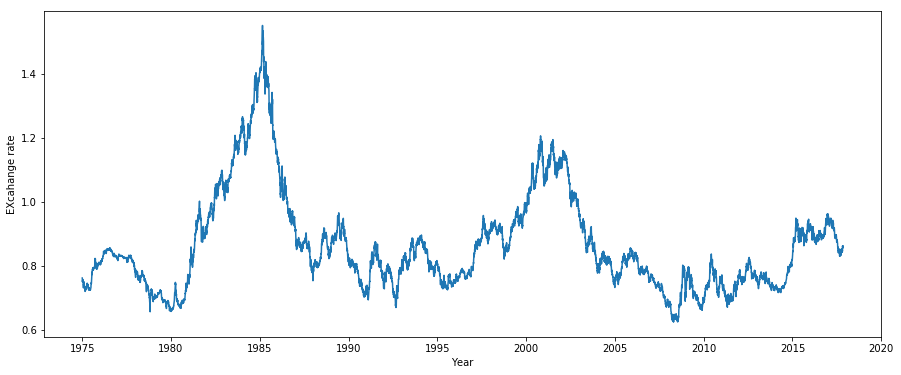

In [32]:
#Plot date v/s value., here plt will take index value directly as x axis
#Visulaize the time series data

ts = indexed_df['Value']
ts.head(5)
plt.xlabel("Year")
plt.ylabel("EXcahange rate")
plt.plot(ts)


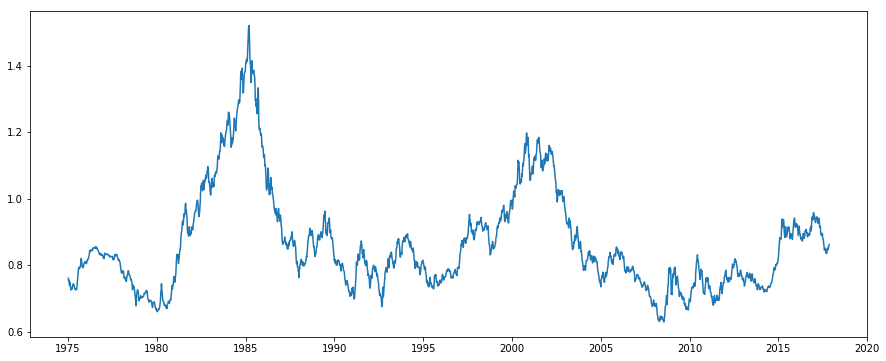

In [33]:
#If data is too many and its overlapping, then we can do resampling mean based on week etc. 
# this is feature 'resample' with mean in python for timeseries type data

ts_week = ts.resample('W').mean()
plt.plot(ts_week)

## 3. STATIONARTY DATA CHECK

### 3.1 Stationarity Check : 
> 1) Rolling Statistic

> 2) Dickey Fuller Test

In [34]:
# Ex: window=12, rolling / cummultaive mean calculated on 12  value basis
rolmean = ts_week.rolling(window=12,center=False).mean() 
print(rolmean.head(30))
#If data is day wise, then window=365, If data is month wise, then window=12, If data is week wise, then window=52

Date
1975-01-05         NaN
1975-01-12         NaN
1975-01-19         NaN
1975-01-26         NaN
1975-02-02         NaN
1975-02-09         NaN
1975-02-16         NaN
1975-02-23         NaN
1975-03-02         NaN
1975-03-09         NaN
1975-03-16         NaN
1975-03-23    0.740987
1975-03-30    0.738808
1975-04-06    0.737492
1975-04-13    0.736450
1975-04-20    0.736484
1975-04-27    0.736654
1975-05-04    0.735950
1975-05-11    0.735384
1975-05-18    0.735037
1975-05-25    0.735234
1975-06-01    0.735250
1975-06-08    0.734892
1975-06-15    0.734782
1975-06-22    0.734108
1975-06-29    0.733453
1975-07-06    0.733248
1975-07-13    0.733681
1975-07-20    0.735593
1975-07-27    0.738761
Freq: W-SUN, Name: Value, dtype: float64


##### 3.1.1 Created funct to check both Rolling statistic and Dickey Fuller test

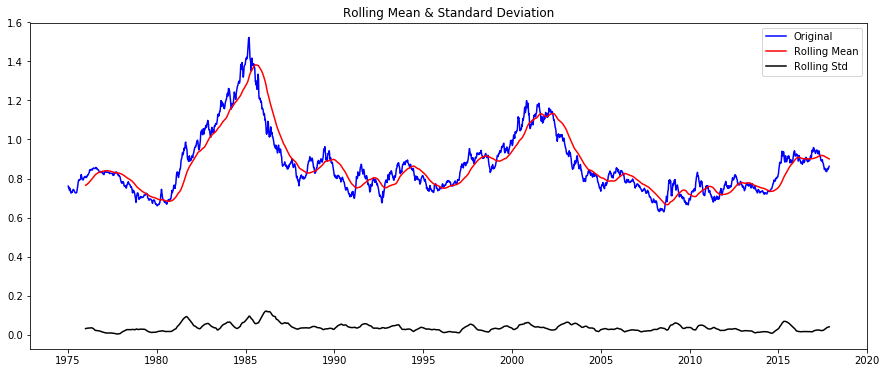

Results of Dickey-Fuller Test:
Test Statistic                   -2.076341
p-value                           0.254134
#Lags Used                        2.000000
Number of Observations Used    2234.000000
Critical Value (1%)              -3.433281
Critical Value (5%)              -2.862835
Critical Value (10%)             -2.567459
dtype: float64


In [35]:
#Test stationarity by 1) plotting rolling mean and rolling std graph 2) Dickey puller test
#Check Stationarity:
#1. Rolling Statistic
#2. ACDF (Dickey Fuller) test

def test_stationarity(timeseries):
    
    #1. Determing rolling statistics
    # DATA IS IN weak WISE,so rolling this data o year wise. so yearly 52 weeks. so window=52
    #window=12 MEANS month wise
    rolmean = timeseries.rolling(window=52,center=False).mean() 
    rolstd = timeseries.rolling(window=52,center=False).std()
    
    #Plot rolling statistics:
    orig = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(rolmean, color='red', label='Rolling Mean')
    std = plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show(block=False)
       
    #2. Perform Dickey-Fuller test:
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    
    #here dftest will have tuple like below with 4 values and 1 dictionary, another value
    """(-2.076340599933076, 
    0.2541339550926388, 
    2, 
    2234, 
    {'1%': -3.4332805415364724, '5%': -2.8628346299364282, '10%': -2.5674591931002038},
    -14013.954809290073)
    """
   
    #Here 1st 4 values are converted to series with giving index name
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])

    # Here 5th value is a dictionary, is converted to each row and appended to  dfoutput
    for key,value in dftest[4].items():
        #Here appends rows "Critical Value (%s)" to dfoutput
        dfoutput['Critical Value (%s)'%key] = value
    
    #print dfout
    print(dfoutput)
test_stationarity(ts_week)

#### Before applying ARIMA model we need to check stationarity of data, mean should be constant.  

> 1 way -->  by plotting mean data after applying rolling mean. 

> 2 way -->  by Dickey Fuller test

### 3.2  Conclusion: 

##### Rolling Statistic

- Here red line - Rolling Mean  is not constant, its fluctuating, so Time series data in not statistic. Only Rolling std is little contant

##### Dicky puller test
- "Test statistic" is less than the 5%critical value. ----> -2.076341  < -2.862835    ---> False

- p-value LESS than 0.05. ----> 0.254134 < 0.05   ---> False

- Both are false, so its Null hypothesis cant be rejected, so its not stationary Time series data

## 4. CONVERT DATA TO STATIONARTY DATA 

### 4.1 To make Stationarity, Can Apply 1) Detrending or 2) Differencing

>  If data in not stationary, then apply 'Detrending' or 'Deferencing' to make it stationary data.

> Here Deferencing is applied, which is log and difference of shift it taken

> Data will be applied with log transformation prior to differencing for better result. Only with log it wont convert data to stationary

> To make stationary some time we need to take log, some time, square, some time cube


TS with log :
  Date
1975-01-05   -0.273253
1975-01-12   -0.283079
1975-01-19   -0.280428
1975-01-26   -0.295876
1975-02-02   -0.302430
Freq: W-SUN, Name: Value, dtype: float64
TS with log and shifted :
  Date
1975-01-05         NaN
1975-01-12   -0.273253
1975-01-19   -0.283079
1975-01-26   -0.280428
1975-02-02   -0.295876
Freq: W-SUN, Name: Value, dtype: float64
TS log after shift :
  Date
1975-01-05         NaN
1975-01-12   -0.009826
1975-01-19    0.002651
1975-01-26   -0.015447
1975-02-02   -0.006555
Freq: W-SUN, Name: Value, dtype: float64


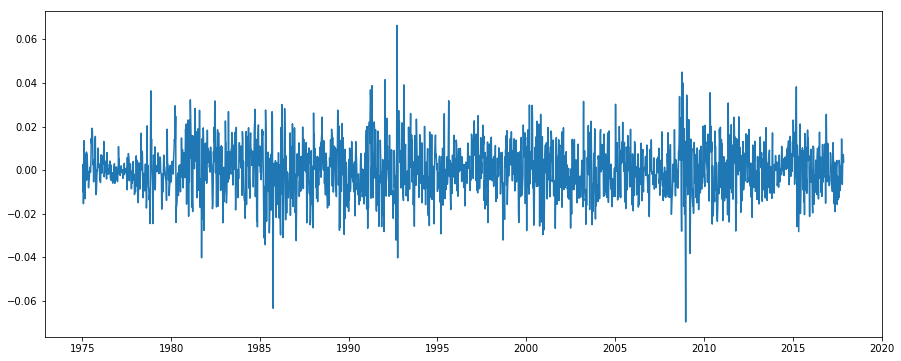

In [36]:
# lOG APPLIED 1st
ts_week_log = np.log(ts_week)

#Shift function of pandas.Dataframe shifts index by desired number of periods with an optional time freq.
# here default 1 index position shifted
ts_week_log_diff = ts_week_log - ts_week_log.shift()

plt.plot(ts_week_log_diff)


print("TS with log :\n " , ts_week_log.head())
print("TS with log and shifted :\n " ,ts_week_log.shift().head())
print("TS log after Difference :\n " ,ts_week_log_diff.head())

### 4.1.1 Remove any null value and check stationarity after differencing

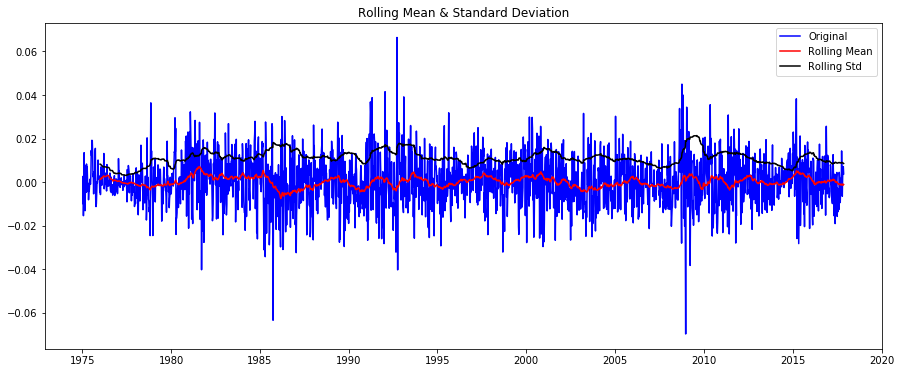

Results of Dickey-Fuller Test:
Test Statistic                  -36.590004
p-value                           0.000000
#Lags Used                        0.000000
Number of Observations Used    2235.000000
Critical Value (1%)              -3.433279
Critical Value (5%)              -2.862834
Critical Value (10%)             -2.567459
dtype: float64


In [37]:
ts_week_log_diff.dropna(inplace=True)

# Call the stationarity checking function
test_stationarity(ts_week_log_diff)

### 4.2  Conclusion: 

##### Rolling Statistic
- Here red line - Rolling mean and Black - Rolling std is constant, its not much fluctuating, so Time series data is statistic, we can apply ARIMA model now

#####  Dicky puller test

- "Test statistic" is less than the 5%critical value.    ---->   -36.590004 <  -2.862834    ---> True

- p-value lesser than 0.05.    ---->  0.000000 < 0.05   ---> True

#####  Both are True, so its Null hypothesis can be rejected, so its a stationary Time series data



## 5. Calculate Lags/order values by ACF PACF

#### ACF and PACF
> To apply ARIMA, we need p logs and q logs, for that we use 'acf and 'pacf' models

> where it crosses upper confidence level in graph,that x axis value  will becomes q values log. 



In [38]:
lag_acf = acf(ts_week_log_diff, nlags=10)
lag_pacf = pacf(ts_week_log_diff, nlags=10, method='ols')

### 5.1 Plot ACF

Text(0.5, 1.0, 'Autocorrelation Function')

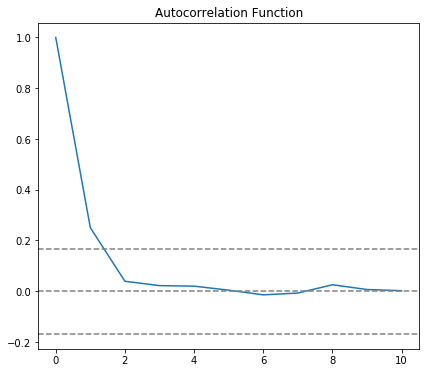

In [39]:
#Plot ACF: 
#where it crosses upper confidence level in graph,that x axis value  will becomes q values log. 

plt.subplot(121) 
plt.plot(lag_acf)
plt.axhline(y=0,linestyle='--',color='gray')
plt.axhline(y=-7.96/np.sqrt(len(ts_week_log_diff)),linestyle='--',color='gray')
plt.axhline(y=7.96/np.sqrt(len(ts_week_log_diff)),linestyle='--',color='gray')
plt.title('Autocorrelation Function')

#### 5.1.1  ACF q Value

> It crosses upper confidence level 0.2 in graph,that x axis value  will becomes q values log. Here its 1

>  So q value= 1(xvalue)


### 5.2 Plot PACF

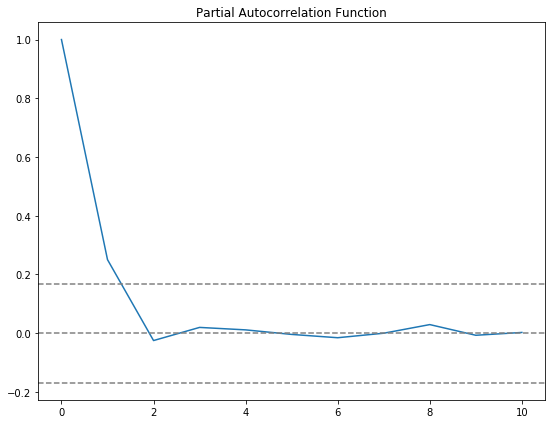

In [40]:
#Plot PACF:
# where it crosses 0 confidence level in graph,that x axis value  will becomes p values log. 

plt.subplot(122)
plt.plot(lag_pacf)
plt.axhline(y=0,linestyle='--',color='gray')
plt.axhline(y=-7.96/np.sqrt(len(ts_week_log_diff)),linestyle='--',color='gray')
plt.axhline(y=7.96/np.sqrt(len(ts_week_log_diff)),linestyle='--',color='gray')
plt.title('Partial Autocorrelation Function')
plt.tight_layout()

#### 5.2.1  PACF p Value

> It crosses 0 confidence level in graph,that x axis value  will becomes p values log. Here its 2

>  So p value= 2(xvalue)

## 6. APPLY ARIMA MODEL

### 6.1 AR model

> Means not applying MA, only AR model applied.  MEANS MA models q set to 0 q=0, 

> only p value p=2 based on PACF function, check RSS

-  Plot original and AR prdicted fitted value and find RSS for this(RSS should be less)

Text(0.5, 1.0, 'RSS: 0.2806')

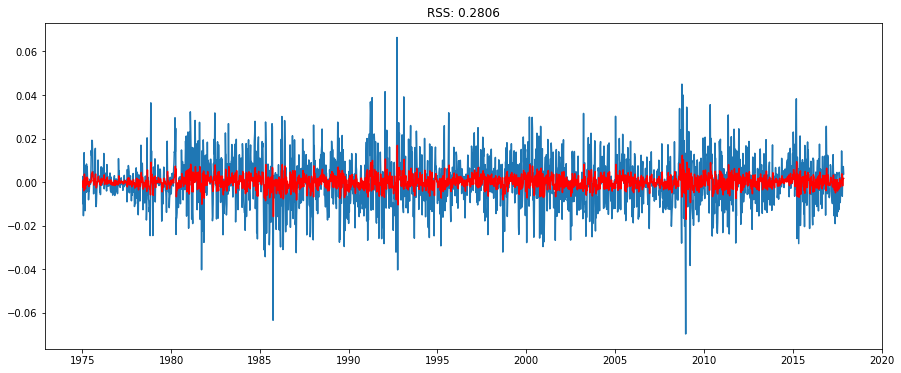

In [41]:
#Apply Arima model with only AR model. 

# (p,d,q) =(2,1,0)
model = ARIMA(ts_week_log, order=(2, 1, 0))  

#Fit the model 
results_ARIMA = model.fit(disp=-1)  

# Plot the ARIMA model
plt.plot(ts_week_log_diff)
plt.plot(results_ARIMA.fittedvalues, color='red')

# RSS is Root Sum of Squared ( predicted- original)**2

plt.title('RSS: %.4f'% sum((results_ARIMA.fittedvalues-ts_week_log_diff)**2))



> For only AR model RSS=0.2806

### 6.2 MA model

> Means not applying AR, only MA model applied.  MEANS AR models p set to 0 p=0, 

> only q value q=1 based on PACF function, check RSS

-  Plot original and MA prdicted fitted value and find RSS for this(RSS should be less)

Text(0.5, 1.0, 'RSS: 0.2810')

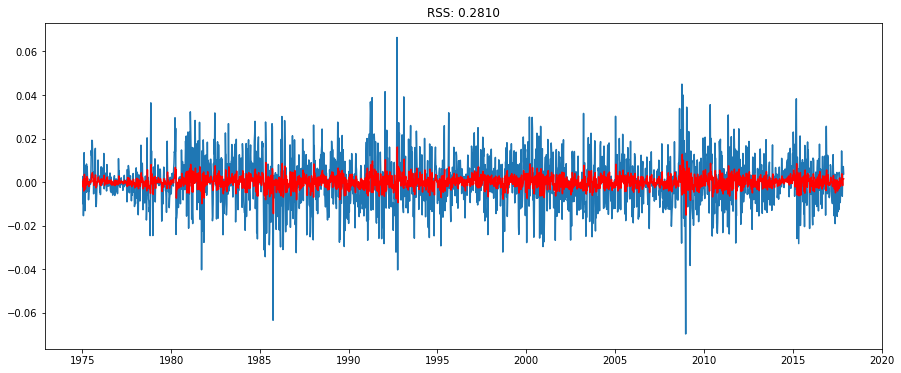

In [42]:
#Apply Arima model with only MA model.  MEANS p=0, only q value, check RSS
# (p,d,q) =(0,1,1)
model = ARIMA(ts_week_log, order=(0, 1, 1))  

#Fit the model 
results_ARIMA = model.fit(disp=-1)  

# Plot the ARIMA model
plt.plot(ts_week_log_diff)
plt.plot(results_ARIMA.fittedvalues, color='red')
plt.title('RSS: %.4f'% sum((results_ARIMA.fittedvalues-ts_week_log_diff)**2))

# for only MA model RSS=0.2810

> For only MA model RSS=0.2810

### 6.3 ARIMA model

> Here apply both AR and MA model together means ARIMA with MA's q=1 and AR's p=2 and check RSS

-  Plot original and ARIMA prdicted fitted value and find RSS for this(RSS should be less)

#### RSS - Residual sum of square, greater RSS then bad for us, smaller RSS is good, this will change based on p,q,d value


Text(0.5, 1.0, 'RSS: 0.2806')

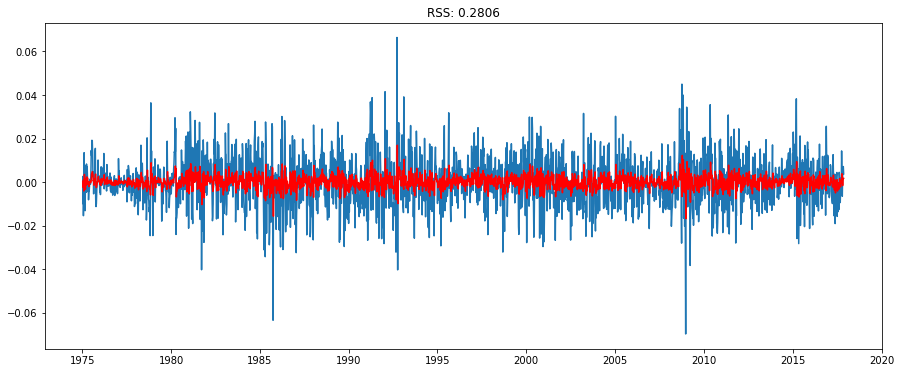

In [43]:
#Apply Arima model with both AR & MA
#Above acf and pacf gave p=2,q=1. (p,d,q) =(2,1,1)


model = ARIMA(ts_week_log, order=(2, 1, 1))  

#Fit the model , results_ARIMA is not predicted result. its fitted model name
results_ARIMA = model.fit(disp=-1)  

# Plot the ARIMA model
plt.plot(ts_week_log_diff)
plt.plot(results_ARIMA.fittedvalues, color='red')
plt.title('RSS: %.4f'% sum((results_ARIMA.fittedvalues-ts_week_log_diff)**2))

# for WITH both AR & MA , ARIMA model RSS=0.2806. HERE its smaller, so smaller RSS is good

### 6.4 ARIMA RSS CONCLUSION

> For only AR model RSS=0.2806

> For only MA model RSS=0.2810

> With Both ARIMA RSS=0.2806

### 6.5 ARIMA MODEL SUMMARY - results_ARIMA.summary

> This summarizes the coefficient values used as well as the skill of the fit on the on the in-sample observations.


In [44]:
#Print the ARIMA model summary
print(results_ARIMA.summary())

                             ARIMA Model Results                              
Dep. Variable:                D.Value   No. Observations:                 2236
Model:                 ARIMA(2, 1, 1)   Log Likelihood                6870.601
Method:                       css-mle   S.D. of innovations              0.011
Date:                Tue, 30 Mar 2021   AIC                         -13731.202
Time:                        21:38:05   BIC                         -13702.640
Sample:                    01-12-1975   HQIC                        -13720.773
                         - 11-12-2017                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const           5.51e-05      0.000      0.178      0.859      -0.001       0.001
ar.L1.D.Value    -0.0901      0.487     -0.185      0.853      -1.044       0.864
ar.L2.D.Value     0.0602      0.128     

### 6.6 ARIMA RESIDUAL ERROR - results_ARIMA.resid

> A residual plot centred around 0 indicates good model(normal distributed with mean centered at 0)

                 0
count  2236.000000
mean      0.000001
std       0.011205
min      -0.061306
25%      -0.006725
50%      -0.000228
75%       0.006869
max       0.064140


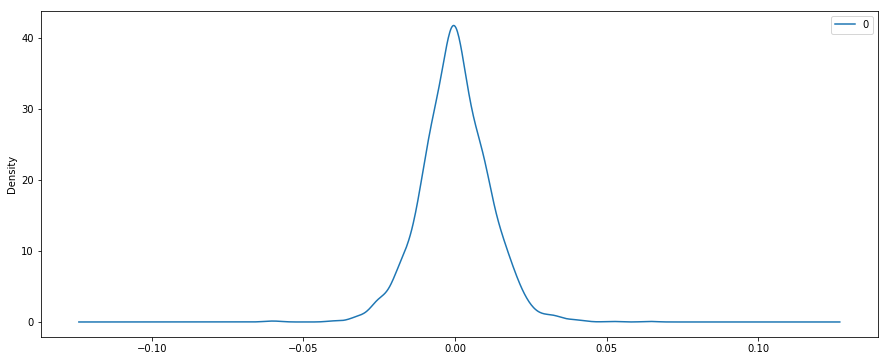

In [45]:
# plot residual errors - Model.resid provides residual error

residuals = DataFrame(results_ARIMA.resid)
residuals.plot(kind='kde')
print(residuals.describe())


### 6.7 ARIMA PREDICTION - results_ARIMA.fittedvalues

> Here fittedvalues are called as Predictions result, but its not actual scale result

In [46]:
#Predictions, but its not in original scale
predictions_ARIMA_diff = pd.Series(results_ARIMA.fittedvalues, copy=True)
print (predictions_ARIMA_diff.head())

Date
1975-01-12    0.000055
1975-01-19   -0.002420
1975-01-26    0.000987
1975-02-02   -0.004103
1975-02-09   -0.001134
Freq: W-SUN, dtype: float64


## 7. Scaling Predictions:

### Rolling Forecast ARIMA Model

- Now that the model is returning the results you want to see, you can scale the model predictions back to original scale.
- Hence remove the first order differencing and take exponent to restore the predictions back to their original scale.

##### 3steps imp for scaling back transformation
> 1. Cummulative sum

> 2. Prediction

> 3. take exponent



 predictions_ARIMA_diff_cumsum: 
 Date
1975-01-12    0.000055
1975-01-19   -0.002365
1975-01-26   -0.001377
1975-02-02   -0.005480
1975-02-09   -0.006615
Freq: W-SUN, dtype: float64

 predictions_ARIMA_log: 
 Date
1975-01-05   -0.273253
1975-01-12   -0.273253
1975-01-19   -0.273253
1975-01-26   -0.273253
1975-02-02   -0.273253
Freq: W-SUN, dtype: float64

 predictions_ARIMA_log after sum: 
 Date
1975-01-05   -0.273253
1975-01-12   -0.273198
1975-01-19   -0.275618
1975-01-26   -0.274631
1975-02-02   -0.278734
Freq: W-SUN, dtype: float64

 predictions_ARIMA after exponent: 
 Date
1975-01-05    0.760900
1975-01-12    0.760942
1975-01-19    0.759103
1975-01-26    0.759853
1975-02-02    0.756741
Freq: W-SUN, dtype: float64


C:\Users\prabh\Anaconda3\lib\site-packages\ipykernel_launcher.py:6: DeprecationWarning: 
.ix is deprecated. Please use
.loc for label based indexing or
.iloc for positional indexing

See the documentation here:
http://pandas.pydata.org/pandas-docs/stable/indexing.html#ix-indexer-is-deprecated
  


Text(0.5, 1.0, 'RMSE: 0.1353')

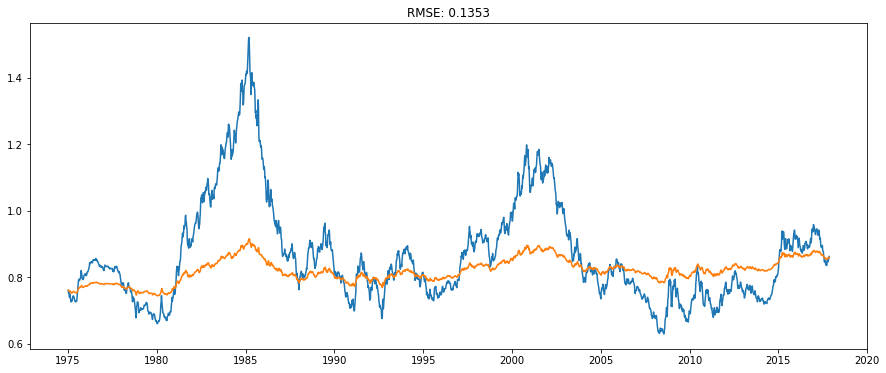

In [47]:

#1. Cummulative rolling sum on prediction
predictions_ARIMA_diff_cumsum = predictions_ARIMA_diff.cumsum()
print("\n predictions_ARIMA_diff_cumsum: \n" , predictions_ARIMA_diff_cumsum.head())

predictions_ARIMA_log = pd.Series(ts_week_log.ix[0], index=ts_week_log.index)
print("\n predictions_ARIMA_log: \n" , predictions_ARIMA_log.head())

#remove the first order differencing 
#2. Prediction sum : it adds predictions_ARIMA_log and predictions_ARIMA_diff_cumsum
predictions_ARIMA_log = predictions_ARIMA_log.add(predictions_ARIMA_diff_cumsum,fill_value=0)
print("\n predictions_ARIMA_log after sum: \n" ,predictions_ARIMA_log.head())

# take exponent, so it will comes back to origial value
#3. take exponent
predictions_ARIMA = np.exp(predictions_ARIMA_log)
print("\n predictions_ARIMA after exponent: \n" ,predictions_ARIMA.head())


plt.plot(ts_week)
plt.plot(predictions_ARIMA)
plt.title('RMSE: %.4f'% np.sqrt(sum((predictions_ARIMA-ts_week)**2)/len(ts_week)))

> Now RMSE with original data is RMSE = 0.1353

## 8. ARIMA model and perform out-of-sample forcasting.

In [57]:
#Split the data to test and train
# Here we are not splitting as randomly. here starting few dataset( based on value in size) as train and 
# remaing all till end as test(it will be like forecasting part)

size = int(len(ts_week_log) - 15)
train, test = ts_week_log[0:size], ts_week_log[size:len(ts_week_log)]
print(train.head())

#Here it converts train data euro value to list
history = [x for x in train]

predictions = list()
print(history[0:10])


Date
1975-01-05   -0.273253
1975-01-12   -0.283079
1975-01-19   -0.280428
1975-01-26   -0.295876
1975-02-02   -0.302430
Freq: W-SUN, Name: Value, dtype: float64
[-0.2732533357996601, -0.2830793479252081, -0.2804284437404728, -0.29587554748030875, -0.3024302948006891, -0.2889361918642178, -0.299188012637983, -0.3073679065685495, -0.32050834038333104, -0.3192690634115926]


### 8.1 APPLY EARLIER ARIMA MODEL WITH SAME p,q,d

> Use Training data to train the ARIMA model and perform out-of-sample forcasting.

> Then you will compare the results of your out-of-sample predictions for EURO rate with the actual values from the test data

In [58]:
#size = int(len(ts_week_log) - 15)
#train, test = ts_week_log[0:size], ts_week_log[size:len(ts_week_log)]
#history = [x for x in train]
#predictions = list()



print('Printing Predicted vs Expected Values...')
print('\n')

#Loop no of time of test size
for t in range(len(test)):
    #Train model with train data which converted as list
    model = ARIMA(history, order=(2,1,1))  #(p,d,q)  # history is train data
    
    #Fit model
    model_fit = model.fit(disp=0)
    
    #forcast, something like predict, 
    # here no need to pass testing one. its future prediction(means test part only)
    
    output = model_fit.forecast()
    #print(output)
    #print(yhat)
    
    #output had 4 value, in that 1st value considered
    yhat = output[0]
    predictions.append(float(yhat))
    
    #Actual test data
    obs = test[t]
    #Not clear
    history.append(obs)
    
print('predicted=%f, expected=%f' % (np.exp(yhat), np.exp(obs)))

Printing Predicted vs Expected Values...


predicted=0.860853, expected=0.862600


## 9 ARIMA model Validation

- Validating the model by comparing out-of-sample predictions for Euro rate with actual values from the test dataset and calculating the mean  squared error

### 9.1 ARIMA model Validation - MSE
#test
#predictions

In [67]:
#Validating the model
error = mean_squared_error(test, predictions)
print('\n')
print('Printing Mean Squared Error of Predictions...')
print('Test MSE: %.6f' % error)




Printing Mean Squared Error of Predictions...
Test MSE: 0.000043


> Mean Squared Error is less =0.000043 . Its a good prediction

### 9.2 ARIMA model Validation -  Plotting forecasting v/s observed value

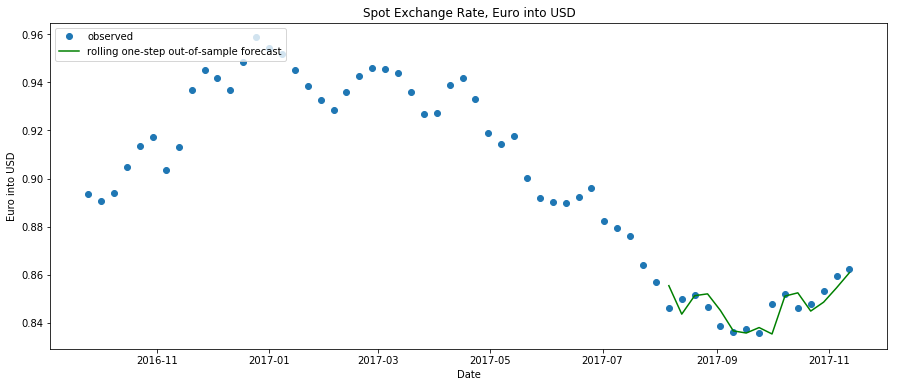

In [68]:
predictions_series = pd.Series(predictions, index = test.index)

fig, ax = plt.subplots()
ax.set(title='Spot Exchange Rate, Euro into USD', xlabel='Date', ylabel='Euro into USD')
ax.plot(ts_week[-60:], 'o', label='observed')
ax.plot(np.exp(predictions_series), 'g', label='rolling one-step out-of-sample forecast')
legend = ax.legend(loc='upper left')
legend.get_frame().set_facecolor('w')

## 10.  FUTURE PREDICTION

#### We can do future prediction
###### plot_predict

In [69]:
ts_week_log.tail()
#To see last year in daatset

Date
2017-10-15   -0.166905
2017-10-22   -0.164898
2017-10-29   -0.158691
2017-11-05   -0.151567
2017-11-12   -0.147804
Freq: W-SUN, Name: Value, dtype: float64

In [70]:
ts_week_log.shape
#total 2237 records in data, we need to predict for another 10 year so steps = 12*10=120

(2237,)

### 10.1 Graphically future  10 year Prediction

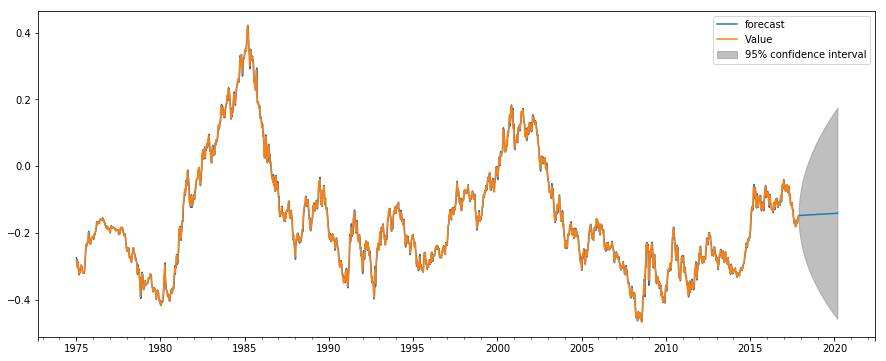

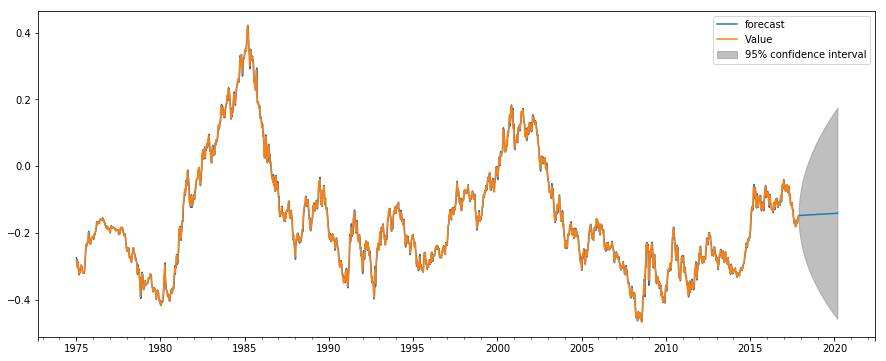

In [71]:
#2237 +120 = 2357
#Not clear on steps

#Graphically future of 10 year
results_ARIMA.plot_predict(1,2357)  # 2237

#Blue line is predicted after 2017

In [46]:
#Array wise future of 10 year
x = results_ARIMA.forecast(steps=120) #10 year prediction
x

(array([-0.14695356, -0.14674698, -0.14665765, -0.14659652, -0.14653991,
        -0.14648458, -0.14642942, -0.14637431, -0.14631921, -0.14626411,
        -0.14620902, -0.14615392, -0.14609882, -0.14604373, -0.14598863,
        -0.14593353, -0.14587844, -0.14582334, -0.14576824, -0.14571315,
        -0.14565805, -0.14560295, -0.14554786, -0.14549276, -0.14543766,
        -0.14538256, -0.14532747, -0.14527237, -0.14521727, -0.14516218,
        -0.14510708, -0.14505198, -0.14499689, -0.14494179, -0.14488669,
        -0.1448316 , -0.1447765 , -0.1447214 , -0.14466631, -0.14461121,
        -0.14455611, -0.14450102, -0.14444592, -0.14439082, -0.14433573,
        -0.14428063, -0.14422553, -0.14417043, -0.14411534, -0.14406024,
        -0.14400514, -0.14395005, -0.14389495, -0.14383985, -0.14378476,
        -0.14372966, -0.14367456, -0.14361947, -0.14356437, -0.14350927,
        -0.14345418, -0.14339908, -0.14334398, -0.14328889, -0.14323379,
        -0.14317869, -0.1431236 , -0.1430685 , -0.1